#  Imports e Configuração de Caminhos

In [1]:
import torch
print("GPU disponível?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nome da GPU:", torch.cuda.get_device_name(0))

GPU disponível? True
Nome da GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
%pip install tqdm scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch

print("CUDA disponível:", torch.cuda.is_available())
print("Dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Apenas CPU")

CUDA disponível: True
Dispositivo: NVIDIA GeForce RTX 5060 Ti


In [4]:
# ============================================================
# CÉLULA 1 — Imports e Configuração (adaptado para VSCode/local)
# ============================================================
import os
import sys
import random
import shutil
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import yaml
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

import ultralytics
print(f"Ultralytics versão: {ultralytics.__version__}")
print(f"OpenCV versão:      {cv2.__version__}")
print(f"Python:             {sys.version}")

# ─── CAMINHOS BASE (ajuste conforme sua máquina) ──────────────
PROJECT_ROOT = Path(__file__).parent if "__file__" in dir() else Path.cwd()
DATA_RAW     = PROJECT_ROOT / "dataset"
WORK         = PROJECT_ROOT / "dataset" / "wood_yolo"
RUNS_DIR     = PROJECT_ROOT / "runs"
MODELS_DIR   = PROJECT_ROOT / "models"

for d in [DATA_RAW, WORK, RUNS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ─── CONFIGURAÇÃO GERAL ───────────────────────────────────────
# ─── CONFIGURAÇÃO GERAL ───────────────────────────────────────
CFG = dict(
    imgsz       = 640,
    epochs      = 150,          # Aumentado para dar mais tempo de convergência
    batch       = -1,           # O valor -1 ativa o AutoBatch (Usa 100% da memória da GPU)
    workers     = 8,            # Aumentado para forçar o uso de múltiplos núcleos da CPU
    val_size    = 0.2,
    seed        = 42,
    model       = "yolov8m.pt", # Trocado para o modelo Medium (melhor precisão)
    min_box_px  = 4,
    conf        = 0.30,
    iou         = 0.55,
)
SEED = CFG["seed"]
random.seed(SEED)
np.random.seed(SEED)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

print("✅ Configuração carregada!")
print(f"   PROJECT_ROOT : {PROJECT_ROOT}")
print(f"   DATA_RAW     : {DATA_RAW}")
print(f"   WORK         : {WORK}")

c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\.venv-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ultralytics versão: 8.4.146
OpenCV versão:      5.0.0
Python:             3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
✅ Configuração carregada!
   PROJECT_ROOT : c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026
   DATA_RAW     : c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset
   WORK         : c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\wood_yolo


# Converter Supervisely JSON para YOLO TXT

In [5]:
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm  # Usando tqdm padrão (não requer ipywidgets)

def process_single_json(json_file, labels_dir, class_to_idx):
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        img_h = data["size"]["height"]
        img_w = data["size"]["width"]

        stem_name = json_file.stem
        if stem_name.endswith(('.bmp', '.jpg', '.png', '.jpeg')):
            stem_name = Path(stem_name).stem

        txt_file = labels_dir / f"{stem_name}.txt"

        yolo_lines = []
        for obj in data.get("objects", []):
            cls_name = obj.get("classTitle")
            if cls_name not in class_to_idx:
                continue
            
            cls_id = class_to_idx[cls_name]
            points = obj.get("points", {}).get("exterior", [])
            if not points or len(points) < 2:
                continue

            xs = [p[0] for p in points]
            ys = [p[1] for p in points]

            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)

            bw = max(0.0, min(1.0, (x_max - x_min) / img_w))
            bh = max(0.0, min(1.0, (y_max - y_min) / img_h))
            xc = max(0.0, min(1.0, (x_min + (x_max - x_min) / 2.0) / img_w))
            yc = max(0.0, min(1.0, (y_min + (y_max - y_min) / 2.0) / img_h))

            yolo_lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

        with open(txt_file, "w", encoding="utf-8") as f:
            f.write("\n".join(yolo_lines))
    except Exception:
        pass

def convert_datasetninja_to_yolo_fast(dataset_path):
    dataset_path = Path(dataset_path)
    meta_path = dataset_path / "meta.json"
    
    classes = ["Quartzity", "Live_Knot", "Marrow", "resin", "Dead_Knot", "knot_with_crack", "Knot_missing", "Crack"]
    if meta_path.exists():
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        classes = [c["title"] for c in meta.get("classes", [])]
    
    class_to_idx = {name: idx for idx, name in enumerate(classes)}

    ann_dir = dataset_path / "ds" / "ann"
    labels_dir = dataset_path / "ds" / "labels"
    labels_dir.mkdir(parents=True, exist_ok=True)

    json_files = list(ann_dir.glob("*.json"))
    print(f"⚡ Convertendo {len(json_files)} anotações em paralelo...")

    with ThreadPoolExecutor() as executor:
        list(tqdm(
            executor.map(lambda f: process_single_json(f, labels_dir, class_to_idx), json_files),
            total=len(json_files),
            desc="Progresso da conversão"
        ))

    print(f"✅ Conversão concluída! Os rótulos foram salvos em: {labels_dir}")

# Executa a conversão otimizada
convert_datasetninja_to_yolo_fast(PROJECT_ROOT / "dataset")

⚡ Convertendo 17926 anotações em paralelo...


Progresso da conversão: 100%|██████████| 17926/17926 [00:08<00:00, 2022.69it/s]

✅ Conversão concluída! Os rótulos foram salvos em: c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\ds\labels


# Funções Utilitárias e Mapeamento

In [6]:
# ============================================================
# CÉLULA 3 — Funções auxiliares e mapeamento imagem↔label
# ============================================================

def find_files(root, exts=None):
    root = Path(root)
    files = []
    for p in root.rglob("*"):
        if p.is_file():
            if exts is None or p.suffix.lower() in exts:
                files.append(p)
    return sorted(files)

def safe_imread(path):
    img = cv2.imread(str(path))
    return img

def read_yolo_txt(path):
    rows = []
    try:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls, xc, yc, bw, bh = parts
                rows.append((int(float(cls)), float(xc), float(yc), float(bw), float(bh)))
    except Exception as e:
        print(f"  Aviso ao ler label {path}: {e}")
    return rows

def keep_box(bw, bh, img_w, img_h, min_px=4):
    return (bw * img_w >= min_px) and (bh * img_h >= min_px) and bw > 0 and bh > 0

def infer_image_map(images_dir):
    return {p.stem: p for p in find_files(images_dir, IMG_EXTS)}

def stem_to_label_path(label_root):
    return {p.stem: p for p in find_files(label_root, {".txt"})}

# ─── Procura imagens e labels dentro do dataset ───────────────
image_map = infer_image_map(DATA_RAW)
label_map = stem_to_label_path(DATA_RAW)

matched = sorted(set(image_map.keys()) & set(label_map.keys()))

print(f"📸 Imagens encontradas : {len(image_map)}")
print(f"🏷️  Labels encontradas  : {len(label_map)}")
print(f"🔗 Pares combinados    : {len(matched)}")
print(f"   Exemplos de stems  : {matched[:5]}")

📸 Imagens encontradas : 20269
🏷️  Labels encontradas  : 20080
🔗 Pares combinados    : 20073
   Exemplos de stems  : ['100000000', '100000001', '100000002', '100000003', '100000004']


# Preparação do Dataset YOLO

In [7]:
# ============================================================
# CÉLULA 4 — Organização em estrutura YOLO (Train / Val / Test)
# ============================================================

TRAIN_IMG = WORK / "images" / "train"
VAL_IMG   = WORK / "images" / "val"
TEST_IMG  = WORK / "images" / "test"

TRAIN_LBL = WORK / "labels" / "train"
VAL_LBL   = WORK / "labels" / "val"
TEST_LBL  = WORK / "labels" / "test"

# Cria as pastas necessárias
for d in [TRAIN_IMG, VAL_IMG, TEST_IMG, TRAIN_LBL, VAL_LBL, TEST_LBL]:
    d.mkdir(parents=True, exist_ok=True)

# Verifica se já foi preparado
if len(list(TRAIN_IMG.glob("*"))) > 100:
    print("✅ Dataset já preparado. Pulando re-preparação.")
else:
    # ─── Coleta registros válidos ─────────────────────────────
    records = []
    for stem in tqdm(matched, desc="Processando pares"):
        img_path = image_map[stem]
        lbl_path = label_map.get(stem)
        img = safe_imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        cleaned = []
        dropped = 0
        if lbl_path and lbl_path.exists():
            for cls, xc, yc, bw, bh in read_yolo_txt(lbl_path):
                if keep_box(bw, bh, w, h, CFG["min_box_px"]):
                    cleaned.append((cls, xc, yc, bw, bh))   # preserva classe original
                else:
                    dropped += 1

        records.append({
            "stem": stem,
            "image_path": str(img_path),
            "label_path": str(lbl_path) if lbl_path else None,
            "has_defect": int(len(cleaned) > 0),
            "num_boxes": len(cleaned),
            "dropped_boxes": dropped,
            "cleaned_rows": cleaned,
        })

    df = pd.DataFrame(records)
    print(f"\n📊 Distribuição:")
    print(df["has_defect"].value_counts().rename({1: "com_defeito", 0: "sem_defeito"}))
    print(f"Boxes descartadas: {df['dropped_boxes'].sum()}")

    # ─── Split estratificado 3-way (65% Train, 15% Val, 20% Test) ───
    # 1. Separa 65% para treino e 35% para (validação + teste)
    train_df, temp_df = train_test_split(
        df, train_size=0.65, random_state=SEED, stratify=df["has_defect"]
    )
    
    # 2. Divide os 35% restantes entre validação (15%) e teste (20%)
    # A proporção de validação dentro desses 35% é 15/35 ≈ 0.4285
    val_ratio_in_temp = 0.15 / 0.35
    val_df, test_df = train_test_split(
        temp_df, train_size=val_ratio_in_temp, random_state=SEED, stratify=temp_df["has_defect"]
    )
    
    print(f"\n✅ Treino: {len(train_df)} (65%) | Validação: {len(val_df)} (15%) | Teste: {len(test_df)} (20%)")

    # ─── Copia arquivos ───────────────────────────────────────
    def write_split(subset_df, img_dir, lbl_dir):
        img_dir, lbl_dir = Path(img_dir), Path(lbl_dir)
        
        # --- INICIALIZA O CLAHE ---
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
        for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
            src = Path(row["image_path"])
            
            # Lê e aplica o pré-processamento
            img = cv2.imread(str(src))
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray_clahe = clahe.apply(gray)
            img_yolo = cv2.cvtColor(gray_clahe, cv2.COLOR_GRAY2BGR)
            
            cv2.imwrite(str(img_dir / src.name), img_yolo)
            
            # Salva os labels
            dst_lbl = lbl_dir / f"{row['stem']}.txt"
            with open(dst_lbl, "w", encoding="utf-8") as f:
                for cls, xc, yc, bw, bh in row["cleaned_rows"]:
                    f.write(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

    print("Copiando imagens de treino...")
    write_split(train_df, TRAIN_IMG, TRAIN_LBL)
    print("Copiando imagens de validação...")
    write_split(val_df, VAL_IMG, VAL_LBL)
    print("Copiando imagens de teste...")
    write_split(test_df, TEST_IMG, TEST_LBL)

print("\n✅ Dataset pronto!")
print(f"   Treino : {len(list(TRAIN_IMG.glob('*')))} imagens")
print(f"   Val    : {len(list(VAL_IMG.glob('*')))} imagens")
print(f"   Teste  : {len(list(TEST_IMG.glob('*')))} imagens")

✅ Dataset já preparado. Pulando re-preparação.

✅ Dataset pronto!
   Treino : 13179 imagens
   Val    : 3041 imagens
   Teste  : 2301 imagens


# Criação do data.yaml


In [8]:
# ============================================================
# CÉLULA 5 — Arquivo de configuração data.yaml
# ============================================================

data_yaml_content = {
    "path": str(WORK.resolve()),  # caminho absoluto
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",       # <-- NOVA PASTA DE TESTE ADICIONADA
    "nc": 8,
    "names": [
        "Quartzity",       # 0
        "Live_Knot",       # 1
        "Marrow",          # 2
        "resin",           # 3
        "Dead_Knot",       # 4
        "knot_with_crack", # 5
        "Knot_missing",    # 6
        "Crack",           # 7
    ],
}

YAML_PATH = WORK / "data.yaml"
with open(YAML_PATH, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False, allow_unicode=True)

print("✅ data.yaml criado em:", YAML_PATH)
print()
with open(YAML_PATH) as f:
    print(f.read())

✅ data.yaml criado em: c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\wood_yolo\data.yaml

names:
- Quartzity
- Live_Knot
- Marrow
- resin
- Dead_Knot
- knot_with_crack
- Knot_missing
- Crack
nc: 8
path: C:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\wood_yolo
test: images/test
train: images/train
val: images/val



# Treinamento YOLOv8

In [ ]:
# ============================================================
# CÉLULA DE TREINAMENTO OTIMIZADA — Alta Resolução e Balanceamento
# ============================================================
import shutil
from pathlib import Path
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else "cpu"

# 1. Troca para o modelo Large para maior capacidade de aprendizado
model = YOLO("yolov8l.pt")

train_results = model.train(
    data=str(YAML_PATH),
    epochs=100,             # Aumentado para dar tempo de convergência
    imgsz=1024,             # Aumentado de 640 para 1024 (Crucial para trincas finas)
    batch=8,                # Reduzido levemente para caber 1024px na VRAM
    workers=8,
    device=device,
    seed=SEED,
    patience=25,
    optimizer="AdamW",      # AdamW converge melhor em conjuntos de dados complexos
    lr0=1e-3,
    lrf=0.01,
    
    # Pesos de Perda (Aumenta o foco no acerto da classe)
    cls=2.0,                # Aumenta o peso da perda de classificação
    box=7.5,
    dfl=1.5,

    # Augmentações Ajustadas para Madeira
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
    degrees=15.0,           # Rotação ajuda a identificar nós em qualquer ângulo
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.8,
    mixup=0.0,              # Zerado: evita misturar texturas de madeira
    copy_paste=0.0,         # Zerado: evita bordas falsas de defeitos

    # Performance e Saída
    project=str(RUNS_DIR),
    name="wood_yolov8l_1024px",
    exist_ok=True,
    plots=True,
    verbose=True,
    cache=True,
    amp=True,
)

BEST_MODEL_PATH = Path(train_results.save_dir) / "weights" / "best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(BEST_MODEL_PATH, MODELS_DIR / "wood_best.pt")
print(f"\n✅ Treinamento otimizado concluído! Modelo salvo em: {MODELS_DIR / 'wood_best.pt'}")

New https://pypi.org/project/ultralytics/8.4.148 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.146  Python-3.12.10 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16283MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\wood_yolo\data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None,

# Validação e Métricas

Ultralytics 8.4.146  Python-3.12.10 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16283MiB)
Model summary (fused): 92 layers, 25,844,392 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1060.1497.6 MB/s, size: 8400.1 KB)
val: Scanning C:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\wood_yolo\labels\val.cache... 3041 images, 319 backgrounds, 496 corrupt: 100% ━━━━━━━━━━━━ 3041/3041  0.0s
val: C:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\wood_yolo\images\val\100000001.bmp: ignoring corrupt image/label: Label class 8 exceeds dataset class count 8. Possible class labels are 0-7
val: C:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\wood_yolo\images\val\100000011.bmp: ignoring corrupt image/label: Label class 9 exceeds dataset class count 8. Possible class labels are 0-7
val: C:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\dataset\wood_yolo\images\val\100000016.bmp: ignoring

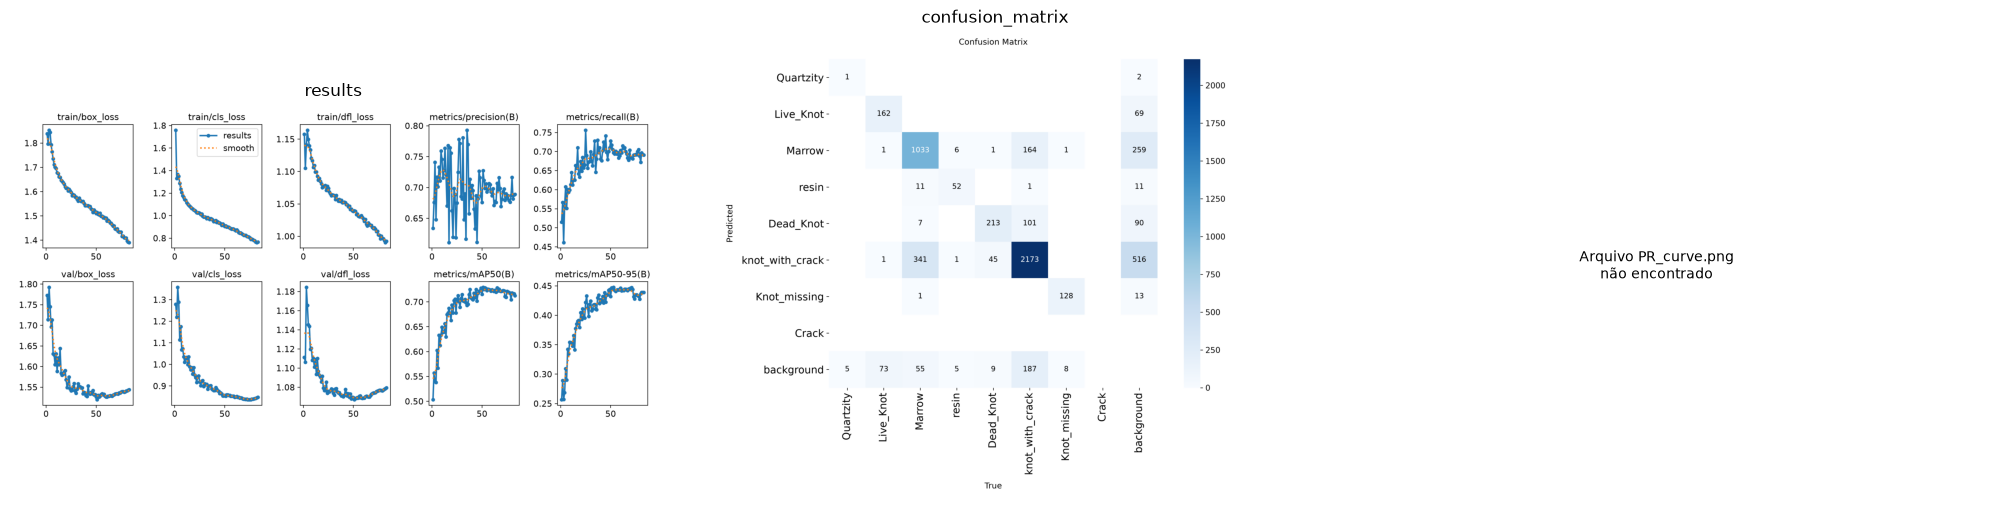

✅ Gráfico salvo em: c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\models\training_summary.png


In [ ]:
# ============================================================
# CÉLULA 7 — Validação e visualização de métricas (Corrigida)
# ============================================================
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

# Carrega o melhor modelo gerado
model_eval = YOLO(str(BEST_MODEL_PATH))

# Garante um batch positivo para a validação (AutoBatch -1 não é aceito no val)
val_batch = CFG["batch"] if isinstance(CFG["batch"], int) and CFG["batch"] > 0 else 16

# Executa a validação do modelo
val_results = model_eval.val(
    data=str(YAML_PATH),
    imgsz=CFG["imgsz"],
    batch=val_batch,
    conf=CFG["conf"],
    iou=CFG["iou"],
    device=device,
    plots=True,
    verbose=True,
)

print("\n📈 Métricas de Validação:")
print(f"  mAP@50    : {val_results.box.map50:.4f}")
print(f"  mAP@50-95 : {val_results.box.map:.4f}")
print(f"  Precision : {val_results.box.mp:.4f}")
print(f"  Recall    : {val_results.box.mr:.4f}")

# Define o diretório base para busca das imagens geradas
if "train_results" in locals() and hasattr(train_results, "save_dir"):
    run_dir = Path(train_results.save_dir)
else:
    run_dir = Path(val_results.save_dir)

# Exibe gráficos inline no VSCode
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_files = ["results.png", "confusion_matrix.png", "PR_curve.png"]

for ax, fname in zip(axes, plot_files):
    fpath = run_dir / fname
    if not fpath.exists():
        fpath = Path(val_results.save_dir) / fname

    if fpath.exists():
        ax.imshow(mpimg.imread(str(fpath)))
        ax.set_title(fname.replace(".png", ""))
    else:
        ax.text(0.5, 0.5, f"Arquivo {fname}\nnão encontrado", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
summary_path = MODELS_DIR / "training_summary.png"
plt.savefig(str(summary_path), dpi=150)
plt.show()

print("✅ Gráfico salvo em:", summary_path)

# Teste em Imagens de Validação

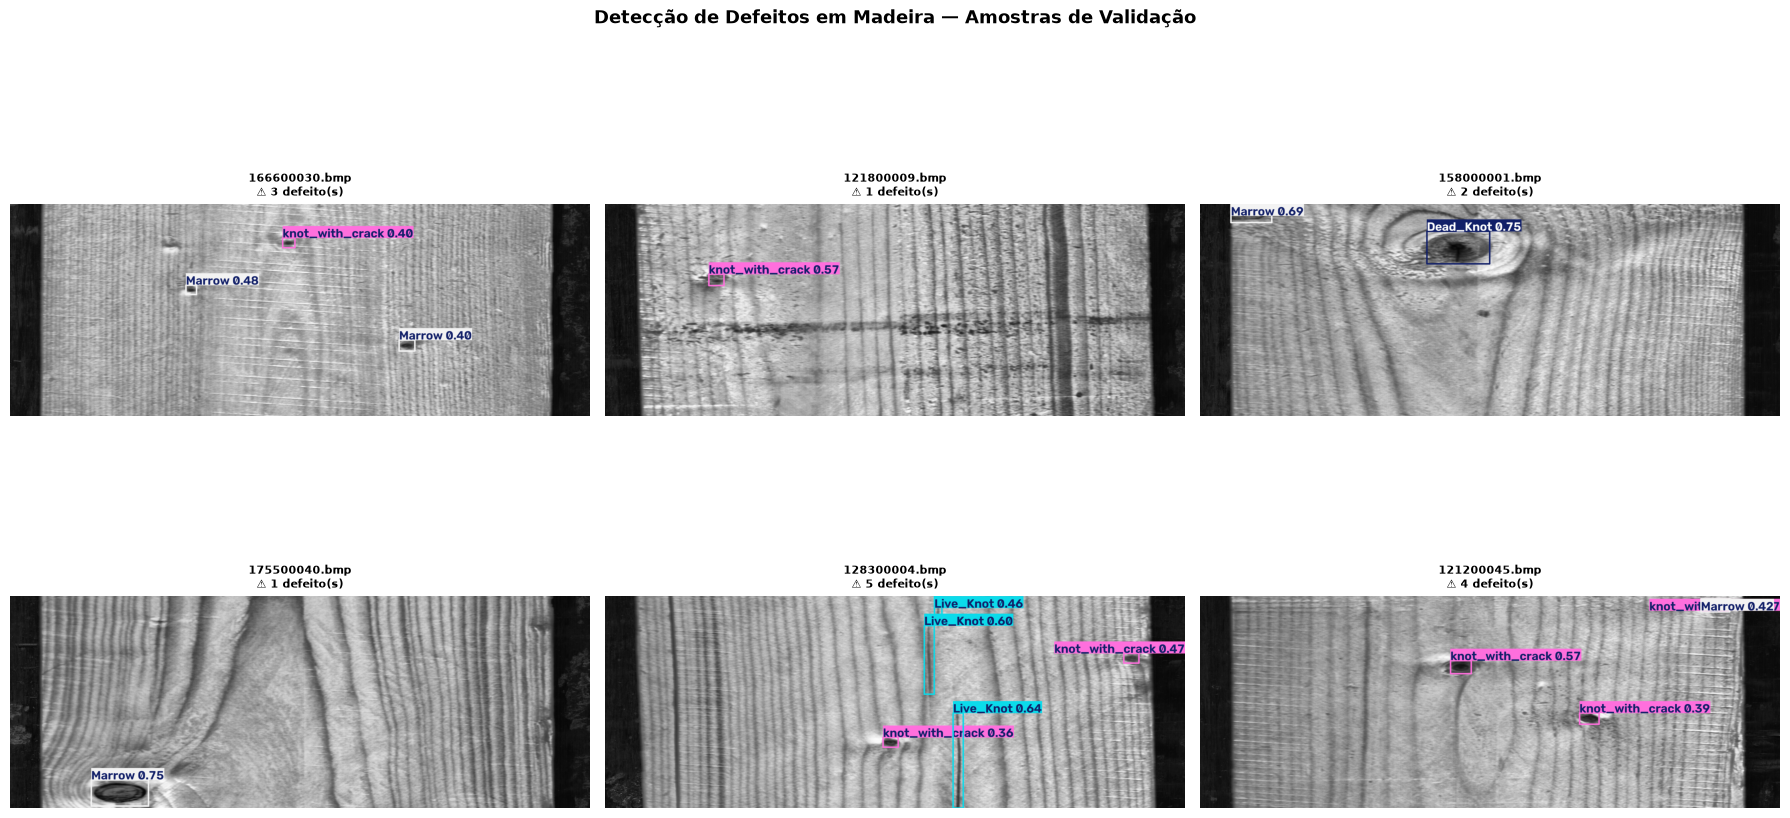

✅ Salvo em: c:\Users\siraj\OneDrive\Desktop\Omni-Root_challenge_2026\models\validation_samples.png


In [ ]:
# ============================================================
# CÉLULA 8 — Teste em imagens do dataset de validação
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches

model_infer = YOLO(str(BEST_MODEL_PATH))
val_imgs = list(VAL_IMG.glob("*"))
sample_imgs = random.sample(val_imgs, min(6, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    preds = model_infer.predict(
        source  = str(img_path),
        conf    = CFG["conf"],
        iou     = CFG["iou"],
        imgsz   = CFG["imgsz"],
        device  = device,
        verbose = False,
    )
    result = preds[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    n = len(result.boxes)
    status = f"⚠️ {n} defeito(s)" if n > 0 else "✅ Sem defeitos"
    ax.imshow(annotated)
    ax.set_title(f"{img_path.name}\n{status}", fontsize=8, fontweight="bold")
    ax.axis("off")

plt.suptitle("Detecção de Defeitos em Madeira — Amostras de Validação", fontsize=13, fontweight="bold")
plt.tight_layout()
out_path = MODELS_DIR / "validation_samples.png"
plt.savefig(str(out_path), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Salvo em:", out_path)

# Detecção em Tempo Real com Webcam (VSCode/Desktop)

In [ ]:
# ============================================================
# CÉLULA 9 — Detecção em Tempo Real com Webcam
# ============================================================
import time
from pathlib import Path
import cv2
import numpy as np
from ultralytics import YOLO

# ─── Carrega modelo ───────────────────────────────────────────
model_path = MODELS_DIR / "wood_best.pt"
if not model_path.exists():
    model_path = BEST_MODEL_PATH  # Usa fallback se 'wood_best.pt' não existir

model_cam = YOLO(str(model_path))

CONF_THRESH = 0.70
IOU_THRESH = 0.55
CAM_INDEX = 0  # Troque para 1, 2... se tiver múltiplas câmeras
WIN_NAME = "Wood Defect Detection — Pressione Q para sair"

cap = cv2.VideoCapture(CAM_INDEX)
if not cap.isOpened():
    raise RuntimeError(
        f"Não foi possível abrir a câmera (índice {CAM_INDEX}).\n"
        "Tente trocar CAM_INDEX para 1 ou 2."
    )

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

print(
    f"🎥 Câmera aberta. Resolução: "
    f"{int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x"
    f"{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}"
)
print("Pressione 'Q' na janela do OpenCV para encerrar.")

prev_time = time.time()
frame_count = 0
fps_display = 0.0

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Falha ao ler frame. Encerrando.")
            break

        frame_count += 1

        # ─── Inferência ──────────────────────────────────────────
        results = model_cam.predict(
            source=frame,
            conf=CONF_THRESH,
            iou=IOU_THRESH,
            imgsz=640,
            device=device,
            verbose=False,
        )
        result = results[0]
        annotated = result.plot(line_width=2)
        n_det = len(result.boxes)

        # ─── Cálculo de FPS ──────────────────────────────────────
        curr_time = time.time()
        if curr_time - prev_time >= 0.5:
            fps_display = frame_count / (curr_time - prev_time)
            frame_count = 0
            prev_time = curr_time

        # ─── HUD (cabeçalho com status) ───────────────────────────
        h, w = annotated.shape[:2]
        bar_color = (0, 50, 200) if n_det > 0 else (0, 160, 50)
        status_txt = f"  DEFEITO DETECTADO: {n_det}" if n_det > 0 else "  SEM DEFEITOS"
        fps_txt = f"FPS: {fps_display:.1f}"

        # Faixa semitransparente no topo
        overlay = annotated.copy()
        cv2.rectangle(overlay, (0, 0), (w, 56), bar_color, -1)
        cv2.addWeighted(overlay, 0.55, annotated, 0.45, 0, annotated)

        cv2.putText(
            annotated, status_txt, (6, 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255, 255, 255), 2, cv2.LINE_AA
        )
        cv2.putText(
            annotated, fps_txt, (w - 120, 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (220, 220, 220), 2, cv2.LINE_AA
        )

        # Confiança das detecções (se houver)
        if n_det > 0:
            confs = result.boxes.conf.cpu().numpy()
            conf_str = "  ".join([f"{c:.2f}" for c in confs[:5]])
            cv2.putText(
                annotated, f"conf: {conf_str}", (6, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (220, 220, 100), 1, cv2.LINE_AA
            )

        # ─── Exibe janela ─────────────────────────────────────────
        cv2.imshow(WIN_NAME, annotated)

        key = cv2.waitKey(1) & 0xFF
        if key in (ord("q"), ord("Q")):
            print("🛑 Encerrado pelo usuário.")
            break

finally:
    # Garante a liberação do hardware e o fechamento correto das janelas no Windows
    cap.release()
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)
    print("✅ Câmera encerrada e recursos liberados.")

RuntimeError: Não foi possível abrir a câmera (índice 0).
Tente trocar CAM_INDEX para 1 ou 2.

#  Carregar Modelo Salvo (Sessões Futuras)

In [ ]:
# ============================================================
# CÉLULA 11 — Carregar modelo já treinado (sem re-treinar)
# Execute apenas esta célula se o modelo já estiver salvo
# ============================================================
from pathlib import Path
from ultralytics import YOLO
import torch

MODELS_DIR = Path("models")  # ajuste se necessário
MODEL_FILE  = MODELS_DIR / "wood_best.pt"

device = "0" if torch.cuda.is_available() else "cpu"

if not MODEL_FILE.exists():
    raise FileNotFoundError(
        f"Modelo não encontrado em {MODEL_FILE}.\n"
        "Execute o treinamento (Célula 6) primeiro."
    )

model_loaded = YOLO(str(MODEL_FILE))
BEST_MODEL_PATH = MODEL_FILE

print(f"✅ Modelo carregado: {MODEL_FILE}")
print(f"🖥️  Dispositivo: {'GPU' if device == '0' else 'CPU'}")
print("ℹ️  Execute a Célula 9 ou 'python webcam_detect.py' para iniciar a webcam.")

✅ Modelo carregado: models\wood_best.pt
🖥️  Dispositivo: GPU
ℹ️  Execute a Célula 9 ou 'python webcam_detect.py' para iniciar a webcam.


# Export para Edge Computing (NCNN — Raspberry Pi)

In [ ]:
# ============================================================
# CÉLULA 10 — Export do modelo para NCNN (Edge Computing)
#
# O que acontece aqui:
#   1. Parte do best.pt (PyTorch, roda na GPU do seu PC)
#   2. Converte para NCNN — formato otimizado para CPUs ARM
#      (exatamente o que o Raspberry Pi 4/5 usa)
#   3. Gera uma pasta  models/wood_ncnn_model/  com dois arquivos:
#        - wood_ncnn_model.ncnn.param  (arquitetura da rede)
#        - wood_ncnn_model.ncnn.bin    (pesos em float16)
#
# Por que NCNN e não TFLite?
#   - NCNN foi criado pela Tencent especificamente para ARM/Linux
#   - Ultralytics exporta nativamente sem dependências extras
#   - 2-4x mais rápido que rodar o .pt direto na CPU do Pi
#   - Não precisa de GPU — roda puro na CPU do Raspberry
#
# Tempo estimado de export: ~2-5 min no seu PC
# ============================================================
from pathlib import Path
from ultralytics import YOLO

# Usa o melhor modelo treinado
# (Se acabou de treinar, BEST_MODEL_PATH já está definido na Célula 6)
# (Se reiniciou o kernel, rode a Célula 11 primeiro para recarregar)
MODEL_TO_EXPORT = BEST_MODEL_PATH  # ex: runs/wood_yolov8m/weights/best.pt

print(f"📦 Exportando: {MODEL_TO_EXPORT}")
print("⏳ Isso pode demorar alguns minutos...")

model_export = YOLO(str(MODEL_TO_EXPORT))

# Export para NCNN
# half=True  → pesos em float16 (metade do tamanho, mesma precisão prática)
# imgsz=640  → mesmo tamanho do treino
export_path = model_export.export(
    format="ncnn",
    imgsz=640,
    half=True,       # float16 — reduz tamanho ~50% sem perda significativa
    dynamic=False,   # batch fixo = mais rápido no Pi
    simplify=True,   # simplifica o grafo ONNX intermediário
)

print(f"\n✅ Export concluído!")
print(f"📁 Pasta gerada: {export_path}")

# Copia a pasta para models/ para facilitar o envio ao Raspberry
import shutil
NCNN_DEST = MODELS_DIR / "wood_ncnn_model"
if NCNN_DEST.exists():
    shutil.rmtree(NCNN_DEST)
shutil.copytree(export_path, NCNN_DEST)

print(f"💾 Cópia salva em: {NCNN_DEST}")
print()
print("📋 Arquivos gerados:")
for f in sorted(NCNN_DEST.rglob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name:40s}  {size_kb:8.1f} KB")
print()
print("🚀 Próximo passo: copie a pasta  models/wood_ncnn_model/  para o Raspberry Pi")
print("   Comando exemplo:")
print("   scp -r models/wood_ncnn_model pi@192.168.1.XX:/home/pi/projeto/models/")


# Teste Local do Modelo NCNN (simula o Raspberry Pi)

In [ ]:
# ============================================================
# CÉLULA 12 — Teste do modelo NCNN (simula o Raspberry Pi)
# ============================================================
import time
import random
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from ultralytics import YOLO

# ─── Garantia de Caminhos e Variáveis ─────────────────────────
WORK = PROJECT_ROOT / "dataset" / "wood_yolo" if "PROJECT_ROOT" in locals() else Path("dataset/wood_yolo")
VAL_IMG = WORK / "images" / "val"
MODELS_DIR = Path("models")
NCNN_MODEL_PATH = MODELS_DIR / "wood_ncnn_model"

if not NCNN_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Pasta NCNN não encontrada em {NCNN_MODEL_PATH}.\n"
        "Execute a Célula 10 (Export NCNN) primeiro."
    )

print("📦 Carregando modelo NCNN (sem GPU)...")
# Força device='cpu' — exatamente como vai rodar no Raspberry
model_ncnn = YOLO(str(NCNN_MODEL_PATH), task="detect")
print("✅ Modelo NCNN carregado!")

# ─── Configurações de inferência ──────────────────────────────
CONF_THRESH = 0.40   # Limiar de confiança
IOU_THRESH  = 0.55   # Limiar de NMS

# ─── Seleciona imagens de validação para teste ────────────────
val_imgs = list(VAL_IMG.glob("*"))
sample_imgs = random.sample(val_imgs, min(6, len(val_imgs)))

# ─── Benchmark de velocidade (simula o Pi) ────────────────────
print("\n⏱️  Benchmark de velocidade (CPU only, como no Raspberry Pi):")
tempos = []
for img_path in sample_imgs[:3]:
    t0 = time.perf_counter()
    model_ncnn.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        imgsz=640,
        device="cpu",
        verbose=False,
    )
    t1 = time.perf_counter()
    tempos.append(t1 - t0)

media_ms = (sum(tempos) / len(tempos)) * 1000
print(f"   Média por frame : {media_ms:.0f} ms")
print(f"   FPS estimado    : {1000/media_ms:.1f} fps\n")

if media_ms < 500:
    print("✅ Velocidade OK para o Raspberry Pi 4/5")
else:
    print("⚠️  Pode ser lento no Pi — considere reduzir imgsz para 320")

# ─── Visualização das detecções ───────────────────────────────
print("\n🔍 Testando detecções nas amostras de validação:")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    preds = model_ncnn.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        imgsz=640,
        device="cpu",
        verbose=False,
    )
    result = preds[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    
    n = len(result.boxes)
    status = f"⚠️ {n} defeito(s)" if n > 0 else "✅ Sem defeitos"
    
    ax.imshow(annotated)
    ax.set_title(f"{img_path.name}\n{status}", fontsize=8, fontweight="bold")
    ax.axis("off")

plt.suptitle("Detecção NCNN (CPU) em Amostras de Validação", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CÉLULA 12 — Teste do modelo NCNN (simula o Raspberry Pi)
# ============================================================
import time
import random
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from ultralytics import YOLO

# ─── Garantia de Caminhos e Variáveis ─────────────────────────
WORK = PROJECT_ROOT / "dataset" / "wood_yolo" if "PROJECT_ROOT" in locals() else Path("dataset/wood_yolo")
VAL_IMG = WORK / "images" / "val"
MODELS_DIR = Path("models")
NCNN_MODEL_PATH = MODELS_DIR / "wood_ncnn_model"

if not NCNN_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Pasta NCNN não encontrada em {NCNN_MODEL_PATH}.\n"
        "Execute a Célula 10 (Export NCNN) primeiro."
    )

print("📦 Carregando modelo NCNN (sem GPU)...")
# Força device='cpu' — exatamente como vai rodar no Raspberry
model_ncnn = YOLO(str(NCNN_MODEL_PATH), task="detect")
print("✅ Modelo NCNN carregado!")

# ─── Configurações de inferência ──────────────────────────────
CONF_THRESH = 0.40   # Limiar de confiança
IOU_THRESH  = 0.55   # Limiar de NMS

# ─── Seleciona imagens de validação para teste ────────────────
val_imgs = list(VAL_IMG.glob("*"))
sample_imgs = random.sample(val_imgs, min(6, len(val_imgs)))

# ─── Benchmark de velocidade (simula o Pi) ────────────────────
print("\n⏱️  Benchmark de velocidade (CPU only, como no Raspberry Pi):")
tempos = []
for img_path in sample_imgs[:3]:
    t0 = time.perf_counter()
    model_ncnn.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        imgsz=640,
        device="cpu",
        verbose=False,
    )
    t1 = time.perf_counter()
    tempos.append(t1 - t0)

media_ms = (sum(tempos) / len(tempos)) * 1000
print(f"   Média por frame : {media_ms:.0f} ms")
print(f"   FPS estimado    : {1000/media_ms:.1f} fps\n")

if media_ms < 500:
    print("✅ Velocidade OK para o Raspberry Pi 4/5")
else:
    print("⚠️  Pode ser lento no Pi — considere reduzir imgsz para 320")

# ─── Visualização das detecções ───────────────────────────────
print("\n🔍 Testando detecções nas amostras de validação:")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    preds = model_ncnn.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        imgsz=640,
        device="cpu",
        verbose=False,
    )
    result = preds[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    
    n = len(result.boxes)
    status = f"⚠️ {n} defeito(s)" if n > 0 else "✅ Sem defeitos"
    
    ax.imshow(annotated)
    ax.set_title(f"{img_path.name}\n{status}", fontsize=8, fontweight="bold")
    ax.axis("off")

plt.suptitle("Detecção NCNN (CPU) em Amostras de Validação", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()